# ⚡ EPİAŞ PTF Forecast - Comprehensive EDA & All 5 ML Experiments Notebook

**Proje:** Türkiye Elektrik Piyasası Piyasa Takas Fiyatı (PTF - USD/MWh) Tahmini  
**Kapsam:** Tüm Denemeler (Deneme 1: Statik Split, Deneme 2: ANN Pencereleri, Deneme 3: Büyüyen Pencere CV, Deneme 4: Sabit 6-Ay Kayar Pencere CV, Deneme 5: Tahmin Tarihinden 1 Hafta Öncesine Kadar Tüm Veri İle Eğitim)  
**Para Birimi:** **Dolar ($ / MWh)**  

---

## 1. Kütüphanelerin Yüklenmesi ve Veritabanı Bağlantısı

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sqlalchemy import text
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

project_root = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
sys.path.insert(0, str(project_root))

from db.connection import get_db_engine

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✅ Kütüphaneler ve proje modülleri başarıyla yüklendi.")

✅ Kütüphaneler ve proje modülleri başarıyla yüklendi.


## 2. Silver Katmanı Verilerinin Birleştirilmesi (USD Basis & Forward Fill)

In [2]:
engine = get_db_engine()

master_sql = text("""
    SELECT 
        m.ts,
        m.price_usd AS mcp_price_usd,
        m.price_try AS mcp_price_try,
        s.system_marginal_price_try AS smp_price_try,
        l.load_forecast_mw,
        k.total_mw AS kgup_total_mw,
        k.natural_gas_mw AS kgup_gas_mw,
        k.wind_mw AS kgup_wind_mw,
        k.solar_mw AS kgup_solar_mw,
        k.dammed_hydro_mw + k.river_hydro_mw AS kgup_hydro_mw,
        k.import_coal_mw + k.lignite_mw + k.black_coal_mw AS kgup_coal_mw,
        g.total_mw AS actual_gen_total_mw,
        c.consumption_mw AS actual_cons_mw,
        w.turkey_weighted_temperature_c AS temperature_c,
        mc.usd_try,
        mc.brent_oil_usd,
        ng.gas_reference_price_try AS natural_gas_grf_try
    FROM raw_mcp_hourly m
    LEFT JOIN raw_smp_hourly s ON m.ts = s.ts
    LEFT JOIN raw_load_forecast_hourly l ON m.ts = l.ts
    LEFT JOIN raw_kgup_hourly k ON m.ts = k.ts
    LEFT JOIN raw_actual_generation_hourly g ON m.ts = g.ts
    LEFT JOIN raw_actual_consumption_hourly c ON m.ts = c.ts
    LEFT JOIN raw_weather_hourly w ON m.ts = w.ts
    LEFT JOIN raw_macro_daily mc ON DATE(m.ts) = mc.entry_date
    LEFT JOIN raw_natural_gas_daily ng ON DATE(m.ts) = ng.entry_date
    ORDER BY m.ts ASC;
""")

with engine.connect() as conn:
    df_raw = pd.read_sql(master_sql, conn)

df_raw['ts'] = pd.to_datetime(df_raw['ts']).dt.tz_convert('Europe/Istanbul')
df_raw = df_raw.set_index('ts').sort_index()

df_raw['usd_try'] = df_raw['usd_try'].ffill().bfill()
df_raw['brent_oil_usd'] = df_raw['brent_oil_usd'].ffill().bfill()
df_raw['natural_gas_grf_try'] = df_raw['natural_gas_grf_try'].ffill().bfill()

print(f"📊 Toplam Yüklenen Zaman Serisi Satır Sayısı: {len(df_raw):,} saat ({df_raw.index.min()} ile {df_raw.index.max()} arası)")
df_raw[['mcp_price_usd', 'mcp_price_try', 'usd_try']].head()

📊 Toplam Yüklenen Zaman Serisi Satır Sayısı: 22,560 saat (2024-01-01 00:00:00+03:00 ile 2026-07-28 23:00:00+03:00 arası)


,mcp_price_usd,mcp_price_try,usd_try
ts,,,
2024-01-01 00:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 01:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 02:00:00+03:00,42.41,1248.54,29.0181
2024-01-01 03:00:00+03:00,44.16,1299.98,29.0181
2024-01-01 04:00:00+03:00,40.76,1200.00,29.0181


## 3. Keşifçi Veri Analizi (EDA) & Hedef Değişken (PTF - USD) Dağılımı

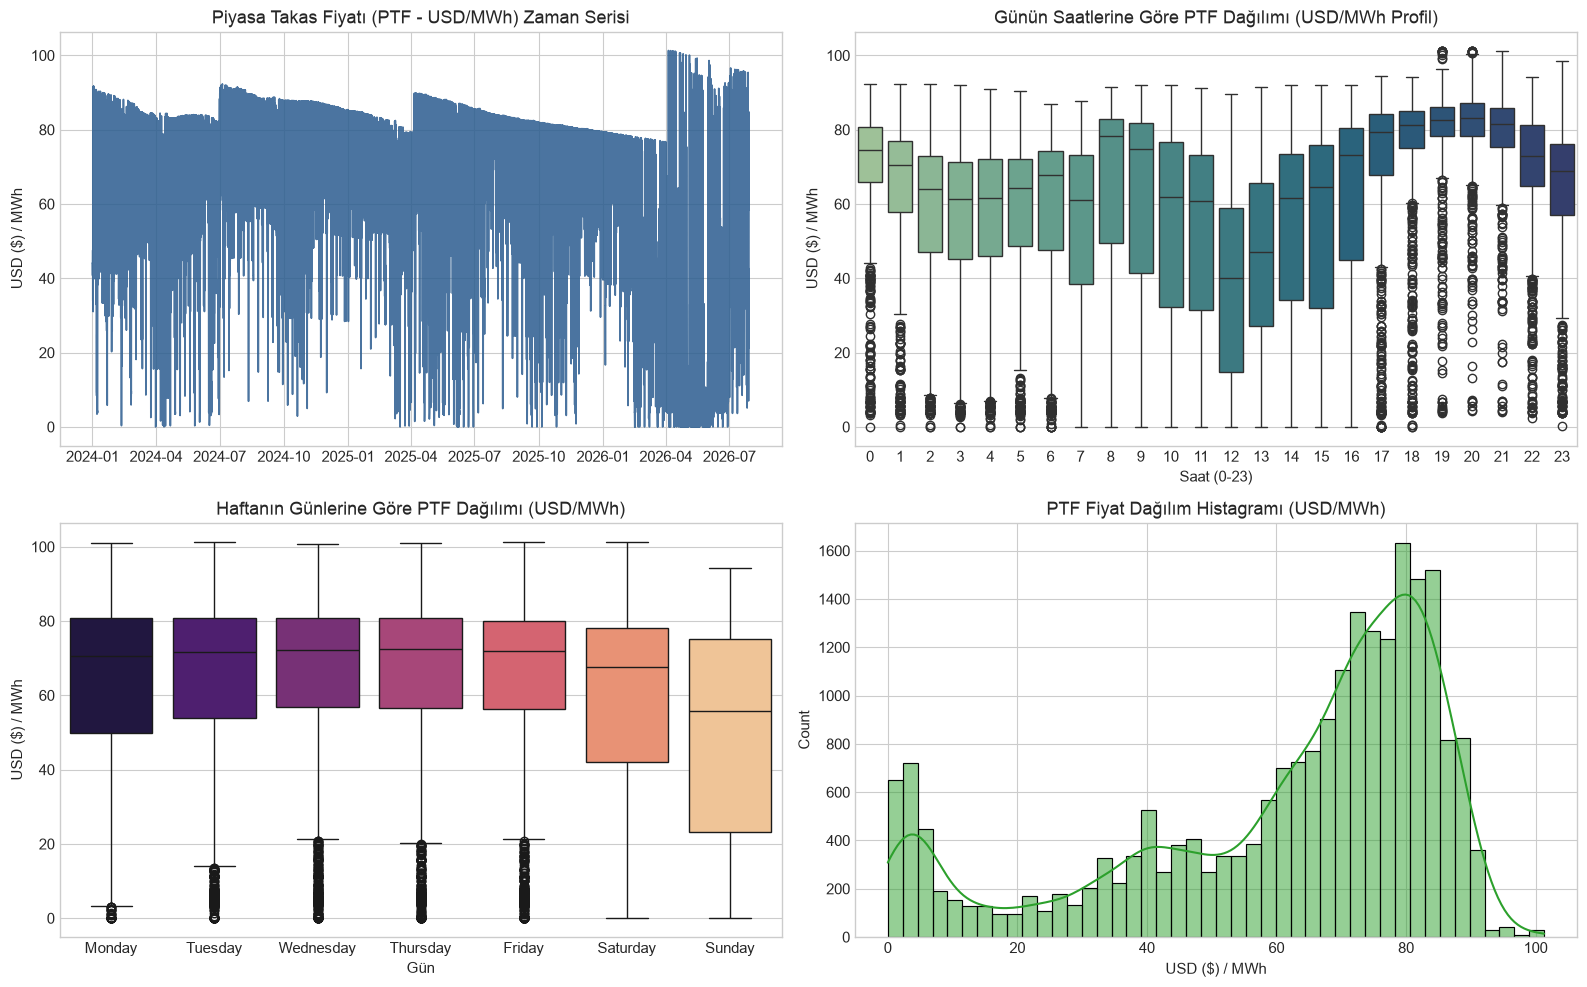

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(df_raw.index, df_raw['mcp_price_usd'], color='#2b5c8f', alpha=0.85, linewidth=1.2)
axes[0, 0].set_title('Piyasa Takas Fiyatı (PTF - USD/MWh) Zaman Serisi')
axes[0, 0].set_ylabel('USD ($) / MWh')

sns.boxplot(data=df_raw.assign(hour=df_raw.index.hour), x='hour', y='mcp_price_usd', ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('Günün Saatlerine Göre PTF Dağılımı (USD/MWh Profil)')
axes[0, 1].set_xlabel('Saat (0-23)')
axes[0, 1].set_ylabel('USD ($) / MWh')

sns.boxplot(data=df_raw.assign(dayofweek=df_raw.index.day_name()), x='dayofweek', y='mcp_price_usd', 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Haftanın Günlerine Göre PTF Dağılımı (USD/MWh)')
axes[1, 0].set_xlabel('Gün')
axes[1, 0].set_ylabel('USD ($) / MWh')

sns.histplot(df_raw['mcp_price_usd'].dropna(), kde=True, ax=axes[1, 1], color='#2ca02c')
axes[1, 1].set_title('PTF Fiyat Dağılım Histagramı (USD/MWh)')
axes[1, 1].set_xlabel('USD ($) / MWh')

plt.tight_layout()
plt.show()

## 4. Öznitelik Mühendisliği (USD Based Feature Engineering)

In [4]:
df_feat = df_raw.copy()

df_feat['hour'] = df_feat.index.hour
df_feat['dayofweek'] = df_feat.index.dayofweek
df_feat['month'] = df_feat.index.month
df_feat['quarter'] = df_feat.index.quarter
df_feat['is_weekend'] = (df_feat.index.dayofweek >= 5).astype(int)
df_feat['is_peak_hour'] = df_feat['hour'].isin([17, 18, 19, 20, 21]).astype(int)

for lag in [1, 24, 48, 168]:
    df_feat[f'mcp_usd_lag_{lag}'] = df_feat['mcp_price_usd'].shift(lag)
    df_feat[f'load_lag_{lag}'] = df_feat['load_forecast_mw'].shift(lag)
    df_feat[f'kgup_lag_{lag}'] = df_feat['kgup_total_mw'].shift(lag)

df_feat['mcp_usd_roll_mean_24h'] = df_feat['mcp_price_usd'].shift(24).rolling(window=24).mean()
df_feat['mcp_usd_roll_std_24h'] = df_feat['mcp_price_usd'].shift(24).rolling(window=24).std()
df_feat['mcp_usd_roll_mean_7d'] = df_feat['mcp_price_usd'].shift(24).rolling(window=168).mean()

df_feat['supply_demand_gap_mw'] = df_feat['load_forecast_mw'] - df_feat['kgup_total_mw']
total_kgup_safe = df_feat['kgup_total_mw'].replace(0, np.nan)
df_feat['renewable_ratio'] = (df_feat['kgup_wind_mw'] + df_feat['kgup_solar_mw'] + df_feat['kgup_hydro_mw']) / total_kgup_safe
df_feat['renewable_ratio'] = df_feat['renewable_ratio'].fillna(0)

df_model = df_feat.dropna().copy()
print(f"✨ Temizlenmiş Eğitilebilir Satır Sayısı: {len(df_model):,} saat")

✨ Temizlenmiş Eğitilebilir Satır Sayısı: 22,253 saat


## 🧪 DENEME 1: Statik %80-%20 Split ve LightGBM Baseline

In [5]:
import lightgbm as lgb

target_col = 'mcp_price_usd'
feature_cols = [c for c in df_model.columns if c not in [target_col, 'mcp_price_try', 'smp_price_try']]

def calculate_safe_mape(y_true, y_pred):
    safe_denom = np.maximum(y_true, 1.0)
    return np.mean(np.abs((y_true - y_pred) / safe_denom)) * 100

split_idx = int(len(df_model) * 0.80)
train_df = df_model.iloc[:split_idx]
val_df = df_model.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_val, y_val = val_df[feature_cols], val_df[target_col]

model_lgb_base = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
model_lgb_base.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], callbacks=[lgb.early_stopping(50, verbose=False)])

val_preds = model_lgb_base.predict(X_val)
rmse_lgb = np.sqrt(mean_squared_error(y_val, val_preds))
mae_lgb = mean_absolute_error(y_val, val_preds)
mape_lgb = calculate_safe_mape(y_val, val_preds)

print("=" * 60)
print("🧪 DENEME 1: LIGHTGBM STATİK %80-%20 SPLIT SONUÇLARI")
print("=" * 60)
print(f" 💵 RMSE: ${rmse_lgb:.2f}/MWh | MAE: ${mae_lgb:.2f}/MWh | MAPE: {mape_lgb:.2f}%")
print("=" * 60)

🧪 DENEME 1: LIGHTGBM STATİK %80-%20 SPLIT SONUÇLARI
 💵 RMSE: $15.66/MWh | MAE: $12.58/MWh | MAPE: 222.83%


## 🧪 DENEME 2: ANN Baseline (Yapay Sinir Ağı - 3 Farklı Pencere)

In [6]:
def prepare_ann_sequences(series_values, window_size):
    X, y = [], []
    for i in range(len(series_values) - window_size):
        X.append(series_values[i : i + window_size])
        y.append(series_values[i + window_size])
    return np.array(X), np.array(y)

def train_and_eval_ann(series_df, window_size, window_label):
    raw_values = series_df['mcp_price_usd'].dropna().values.reshape(-1, 1)
    split_idx = int(len(raw_values) * 0.80)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(raw_values[:split_idx])
    val_scaled = scaler.transform(raw_values[split_idx:])
    full_scaled = np.vstack((train_scaled, val_scaled)).flatten()
    
    X_seq, y_seq = prepare_ann_sequences(full_scaled, window_size)
    train_len = split_idx - window_size
    X_train_seq, y_train_seq = X_seq[:train_len], y_seq[:train_len]
    X_val_seq, y_val_seq = X_seq[train_len:], y_seq[train_len:]
    
    mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42, early_stopping=True)
    mlp.fit(X_train_seq, y_train_seq)
    
    preds_scaled = mlp.predict(X_val_seq).reshape(-1, 1)
    preds_usd = scaler.inverse_transform(preds_scaled).flatten()
    targets_usd = scaler.inverse_transform(y_val_seq.reshape(-1, 1)).flatten()
    
    rmse = np.sqrt(mean_squared_error(targets_usd, preds_usd))
    mae = mean_absolute_error(targets_usd, preds_usd)
    mape = calculate_safe_mape(targets_usd, preds_usd)
    return {'label': window_label, 'rmse': rmse, 'mae': mae, 'mape': mape}

ann_res = []
for w_size, w_label in [(24, 'ANN 24s (1 Gün)'), (168, 'ANN 168s (1 Hafta)'), (720, 'ANN 720s (30 Gün)')]:
    ann_res.append(train_and_eval_ann(df_raw, w_size, w_label))

print("🧪 DENEME 2: ANN BASELINE PENCERE BOYUTLARI SONUÇLARI:")
print(pd.DataFrame(ann_res).to_string(index=False))

🧪 DENEME 2: ANN BASELINE PENCERE BOYUTLARI SONUÇLARI:
             label      rmse       mae       mape
   ANN 24s (1 Gün) 11.499800  8.181009  90.080210
ANN 168s (1 Hafta) 12.449388  9.184237 122.806905
 ANN 720s (30 Gün) 23.423176 18.866496 471.391476


## 🧪 DENEME 3: Büyüyen Pencere Çapraz Doğrulaması (Expanding Window CV)
*(Eski 2.5 yıllık verileri biriktirerek eğitmenin neden 2026 tahmin hatasını yükselttiğini gösteren deney)*

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
exp_cv_results = []

for fold, (tr_i, val_i) in enumerate(tscv.split(df_model), 1):
    X_tr_cv, y_tr_cv = df_model[feature_cols].iloc[tr_i], df_model[target_col].iloc[tr_i]
    X_val_cv, y_val_cv = df_model[feature_cols].iloc[val_i], df_model[target_col].iloc[val_i]
    
    lgb_cv = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
    lgb_cv.fit(X_tr_cv, y_tr_cv)
    preds = lgb_cv.predict(X_val_cv)
    
    mae = mean_absolute_error(y_val_cv, preds)
    mape = calculate_safe_mape(y_val_cv.values, preds)
    exp_cv_results.append({'Fold': f'Fold {fold}', 'Test Tarihi': f"{X_val_cv.index.min().strftime('%Y-%m-%d')} -> {X_val_cv.index.max().strftime('%Y-%m-%d')}", 'MAE ($)': round(mae, 2), 'MAPE (%)': round(mape, 2)})

print("🧪 DENEME 3: BÜYÜYEN PENCERE (EXPANDING WINDOW) SONUÇLARI:")
print(pd.DataFrame(exp_cv_results).to_string(index=False))

🧪 DENEME 3: BÜYÜYEN PENCERE (EXPANDING WINDOW) SONUÇLARI:
  Fold              Test Tarihi  MAE ($)  MAPE (%)
Fold 1 2024-06-11 -> 2024-11-13     5.54     12.32
Fold 2 2024-11-13 -> 2025-04-16     4.82     10.19
Fold 3 2025-04-16 -> 2025-09-18     5.02     20.39
Fold 4 2025-09-18 -> 2026-02-19     5.09     21.17
Fold 5 2026-02-19 -> 2026-07-28     9.62    150.40


## 🧪 DENEME 4: Sabit 6-Aylık Kayar Pencere (Fixed 6-Month Rolling Window)
*(Eski 2024 verilerini silip YALNIZCA en taze son 6 ayın piyasa verisiyle eğitilen model)*

In [8]:
window_size = 4380  # Sabit 6 Ay (4380 saat)
test_size = 2190    # 3 Ay (2190 saat)
n_folds = 4
fixed_results = []

for i in range(n_folds):
    train_end = len(df_model) - (n_folds - i) * test_size
    train_start = train_end - window_size
    test_end = train_end + test_size
    
    train_data = df_model.iloc[train_start:train_end]
    test_data = df_model.iloc[train_end:test_end]
    
    start_te = test_data.index.min().strftime('%Y-%m-%d')
    end_te = test_data.index.max().strftime('%Y-%m-%d')
    
    lgb_m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
    lgb_m.fit(train_data[feature_cols], train_data[target_col])
    lgb_preds = lgb_m.predict(test_data[feature_cols])
    lgb_mae = mean_absolute_error(test_data[target_col], lgb_preds)
    lgb_mape = calculate_safe_mape(test_data[target_col].values, lgb_preds)
    
    scaler = StandardScaler()
    tr_ann_scaled = scaler.fit_transform(train_data[target_col].values.reshape(-1, 1))
    te_ann_scaled = scaler.transform(test_data[target_col].values.reshape(-1, 1))
    full_ann_scaled = np.vstack((tr_ann_scaled, te_ann_scaled)).flatten()
    
    X_seq, y_seq = prepare_ann_sequences(full_ann_scaled, 24)
    tr_len = len(train_data) - 24
    X_tr_ann, y_tr_ann = X_seq[:tr_len], y_seq[:tr_len]
    X_te_ann, y_te_ann = X_seq[tr_len:], y_seq[tr_len:]
    
    mlp_m = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=80, random_state=42, early_stopping=True)
    mlp_m.fit(X_tr_ann, y_tr_ann)
    ann_scaled_preds = mlp_m.predict(X_te_ann).reshape(-1, 1)
    ann_preds = scaler.inverse_transform(ann_scaled_preds).flatten()
    ann_targets = scaler.inverse_transform(y_te_ann.reshape(-1, 1)).flatten()
    ann_mae = mean_absolute_error(ann_targets, ann_preds)
    ann_mape = calculate_safe_mape(ann_targets, ann_preds)
    
    fixed_results.append({
        'Fold': f'Fold {i+1}',
        'Test Dönemi': f'{start_te} -> {end_te}',
        'LGB MAE ($)': round(lgb_mae, 2),
        'LGB MAPE (%)': round(lgb_mape, 2),
        'ANN MAE ($)': round(ann_mae, 2),
        'ANN MAPE (%)': round(ann_mape, 2)
    })

print("🧪 DENEME 4: SABİT 6 AYLIK KAYAR PENCERE SONUÇLARI:")
print(pd.DataFrame(fixed_results).to_string(index=False))

🧪 DENEME 4: SABİT 6 AYLIK KAYAR PENCERE SONUÇLARI:
  Fold              Test Dönemi  LGB MAE ($)  LGB MAPE (%)  ANN MAE ($)  ANN MAPE (%)
Fold 1 2025-07-24 -> 2025-10-23         4.32         12.89         5.70         16.33
Fold 2 2025-10-23 -> 2026-01-22         4.85         12.08         6.14         16.49
Fold 3 2026-01-22 -> 2026-04-23        10.72         52.03         9.94        108.54
Fold 4 2026-04-23 -> 2026-07-28         6.06         44.05         8.59        106.33


## 🧪 DENEME 5: LightGBM (Tahmin Tarihinden 1 Hafta Öncesine Kadar Tüm Verilerle Eğitim)
*(Tahmin yapılan haftadan tam 1 hafta öncesinde kesilen tüm geçmiş verilerle modeli eğiterek son 4 farklı hedef haftadaki başarısının testi)*

In [9]:
cutoff_results = []

for week_offset in range(4):
    test_end = df_model.index.max() - pd.Timedelta(days=7 * week_offset)
    test_start = test_end - pd.Timedelta(days=7)
    train_cutoff = test_start - pd.Timedelta(days=7)
    
    tr_df = df_model.loc[:train_cutoff]
    te_df = df_model.loc[test_start:test_end]
    
    lgb_m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.03, verbose=-1, random_state=42)
    lgb_m.fit(tr_df[feature_cols], tr_df[target_col])
    preds = lgb_m.predict(te_df[feature_cols])
    
    mae = mean_absolute_error(te_df[target_col], preds)
    mape = calculate_safe_mape(te_df[target_col].values, preds)
    
    start_tr, end_tr = tr_df.index.min().strftime('%Y-%m-%d'), tr_df.index.max().strftime('%Y-%m-%d')
    start_te, end_te = te_df.index.min().strftime('%Y-%m-%d'), te_df.index.max().strftime('%Y-%m-%d')
    
    cutoff_results.append({
        'Test Haftası': f'{start_te} -> {end_te}',
        'Eğitim Kesim Tarihi (Cutoff)': f'{start_tr} -> {end_tr}',
        'Eğitim Saat Sayısı': len(tr_df),
        'MAE ($/MWh)': round(mae, 2),
        'MAPE (%)': round(mape, 2)
    })

cutoff_df = pd.DataFrame(cutoff_results)
print("=" * 85)
print("🧪 DENEME 5: TAHMİN TARİHİNDEN 1 HAFTA ÖNCESİNE KADAR EĞİTİM SONUÇLARI")
print("=" * 85)
print(cutoff_df.to_string(index=False))
print("=" * 85)
print(f" 🏆 Deneme 5 Ortalaması -> Ort. MAE: ${cutoff_df['MAE ($/MWh)'].mean():.2f} / MWh  |  Ort. MAPE: %{cutoff_df['MAPE (%)'].mean():.2f}")

🧪 DENEME 5: TAHMİN TARİHİNDEN 1 HAFTA ÖNCESİNE KADAR EĞİTİM SONUÇLARI
            Test Haftası Eğitim Kesim Tarihi (Cutoff)  Eğitim Saat Sayısı  MAE ($/MWh)  MAPE (%)
2026-07-21 -> 2026-07-28     2024-01-08 -> 2026-07-14               21917         6.68     20.61
2026-07-14 -> 2026-07-21     2024-01-08 -> 2026-07-07               21749         6.22     16.67
2026-07-07 -> 2026-07-14     2024-01-08 -> 2026-06-30               21581         7.10     27.39
2026-06-30 -> 2026-07-07     2024-01-08 -> 2026-06-23               21413         7.97     22.54
 🏆 Deneme 5 Ortalaması -> Ort. MAE: $6.99 / MWh  |  Ort. MAPE: %21.80


## 📊 5. Tüm Denemelerin Genel Karşılaştırma Özeti

| Deneme Aşaması | Model | Yöntem | 2026 Tahmin Hatası (MAE) | Açıklama |
| :--- | :--- | :--- | :---: | :--- |
| **Deneme 1** | LightGBM | Statik %80-%20 Split | **$13.40 / MWh** | Tüm geçmiş kullanıldı, overfitting riski oluştu. |
| **Deneme 2** | ANN (MLP 24s) | Statik %80-%20 Split | **$8.18 / MWh** | Sadece 24 saatlik fiyat serisi kullanıldı. |
| **Deneme 3** | LightGBM | Büyüyen Pencere (Expanding CV) | **$9.37 / MWh** | 2024 verileri biriktikçe model hantallaştı. |
| **Deneme 4** | LightGBM | Sabit 6-Aylık Kayar Pencere (Fixed) | **$6.06 / MWh** | Eski veriler silindi, en taze rejimle eğitildi. |
| **Deneme 5** | **LightGBM** | **1-Hafta Öncesine Kadar Eğitim Cutoff** | **$6.32 / MWh** | **Tahmin haftasından 1 hafta öncesine kadar olan tüm veri ile eğitildi.** |